# NPV winner check — does the SMR-vs-large winner survive non-CAPEX costs?

**Purpose.** The Monte Carlo (`mc_cost_trajectories.ipynb`) and the boundary analysis
(`winner_boundary.ipynb`) pick each draw's winner on **financed CAPEX alone**. ReEDS's actual
objective is the **NPV of all costs** — capital *plus* fixed O&M, variable O&M, and fuel, with
generation limited by each technology's availability. This notebook re-ranks every draw on that
fuller NPV and asks one question: **does the winner change?**

Two modeling commitments, both fixed before any result was computed:

1. **Capacity factor = availability factor, computed exactly the way ReEDS computes `avail`**
   (`reeds/core/solve/2_temporal_params.gms`, line 381):
   `avail(i,r,h) = (1 − outage_forced_h(i,r,h)) · (1 − outage_scheduled_h(i,h))` — a
   temperature-dependent forced-outage curve applied to hourly state temperatures, times a
   monthly refueling profile. Section N1 rebuilds this from ReEDS's own raw inputs and checks it
   against a materialized run, bit for bit.
2. **O&M rides the same dial as the anchor cost** (decision 2026-08-03): in a draw whose 2030
   anchor cost sits at the *p*-th percentile of its range, FOM and VOM sit at the *p*-th
   percentile of *their* ranges (ATB 2024 advanced → conservative). They are **not** independent
   sensitivities — an expensive-anchor world is also an expensive-O&M world. This is a natural
   extension of the MC's own design: the anchor-cost ranges *are* the ATB advanced and
   conservative 2030 capital costs, so one percentile already indexes the whole ATB scenario
   axis (checked in N2).

**Prerequisite:** run `mc_cost_trajectories.ipynb` first — it writes `exports/mc_perdraw.npz`
(S10b), which this notebook reads. Nothing here re-runs the MC engine.

### Glossary

| term | meaning |
|---|---|
| **`avail`** | the fraction of a year a plant is physically able to run: (1 − forced outage) × (1 − scheduled outage). ReEDS computes it hourly; collapsed to an annual mean it is the capacity-factor ceiling. Identical for both techs by ReEDS's own construction (both map to the `nuclear` prime mover) |
| **FOM** | fixed O&M, \$/kW-yr — paid on capacity whether or not it runs |
| **VOM** | variable O&M, \$/MWh — paid on generation |
| **fuel** | heat rate (MMBtu/MWh) × uranium price (\$/MMBtu). SMR's lower heat rate (9.18 vs 10.497) makes its fuel ~0.6 \$/MWh cheaper at the same uranium price |
| **`1/crf`** | ReEDS's annual-to-lifetime factor: in sequential mode the objective charges `pvf_onm = 1/crf ≈ 14.76` dollars of lifetime PV per dollar of annual O&M (30-yr window, 5.36% real) |
| **`U1` — the cost dial** | the one copula uniform that sets *both* techs' 2030 anchor costs — and now, by the convention above, both techs' FOM and VOM |
| **program cost `R`** | per-draw cost of building the whole schedule with one tech: \$/kW cost weighted by annual GW additions, discounted to 2030. CAPEX-only `R` is the MC's ranking; here it becomes `R_npv` = financed CAPEX + 30-yr PV of O&M and fuel |

### Sign convention

> **`m > 0` ⇒ SMR wins**, exactly as in `winner_boundary.ipynb`; **large = blue, SMR =
> orange**. "Flip" always means the winner under NPV differs from the winner under CAPEX.

**Why the answer is almost knowable in advance** — and worth checking anyway: the O&M add-on is
deterministic given the draw (affine in `U1`), so NPV ranking = CAPEX ranking + a per-tech shift
that varies along the cost dial. At the cheap end SMR's FOM range starts lower (118 vs 126
\$/kW-yr) but at the expensive end it is *worse* (216 vs 204); VOM tilts the other way; fuel
always favors SMR. Which effect wins, where, and whether any draws actually flip — that is what
the data below settles.


## N1 — Replicating ReEDS's availability factor

**The question.** What annual capacity factor does ReEDS itself believe a nuclear plant can
achieve — and is it different for the two technologies?

**What you'll see.** The forced-outage-vs-temperature curve (Murphy et al. 2019) that ReEDS
extrapolates and applies to hourly state temperatures; the monthly refueling profile; the
resulting per-state annual availability. Then a QA cell that reproduces the outage tables of an
actual materialized run (`runs/utshake_ut_learn`) **exactly**, so the replication is verified
against ReEDS's own pipeline, not against a paraphrase of it.

**How to read it.** One number matters downstream: the annual-mean availability, used as the
capacity factor for both techs. Everything else is evidence that the number is ReEDS's, not
ours. Both techs get the *same* availability because ReEDS maps `nuclear` and `nuclear-smr` to
the same `nuclear` prime mover — so CF never favors either side.


In [1]:
import json
import numpy as np
import pandas as pd
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path

NB_DIR = Path.cwd().resolve()
REPO = NB_DIR.parents[1]
EXPORTS = NB_DIR / "exports"
NPZ = EXPORTS / "mc_perdraw.npz"
assert NPZ.exists(), "exports/mc_perdraw.npz not found - run mc_cost_trajectories.ipynb (S10b) first"

# --- Figure formatting: the z-ethan house standard (single source: ../plotstyle.py) ---
import sys
if str(NB_DIR.parent) not in sys.path:
    sys.path.insert(0, str(NB_DIR.parent))
import plotstyle as ps
ps.apply()
COL = ps.COL                                   # local aliases keep downstream cells unchanged
INK, MUTED, FAINT, GRID_C, EDGE_C, SURFACE = (ps.INK, ps.MUTED, ps.FAINT, ps.GRID_C,
                                              ps.EDGE_C, ps.SURFACE)

# ============ ReEDS's avail, from ReEDS's own raw inputs ============
# Ported from reeds/input_processing/outage_rates.py + reeds/io.py::get_temperatures
# (defaults: GSw_OutageScen=murphy2019; resource_adequacy_years from cases.csv row 392).
TZ_OUT = "Etc/GMT+6"
TEMP_MIN, TEMP_MAX, MAX_FOR = -50, 60, 0.4
RA_YEARS = [2007, 2008, 2009, 2010, 2011, 2012, 2013,
            2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

# 1) forced-outage curve: linear end-slope extrapolation to [-50, 60] degC, clipped to 0.4
fits_in = (
    pd.read_csv(REPO / "inputs/plant_characteristics/outage_forced_temperature_murphy2019.csv",
                comment="#")
    .pivot(index="deg_celsius", columns="prime_mover", values="outage_frac")
)

def extrapolate_forward_backward(dfin, xmin, xmax, numfitvals=2, ymin=0.0, ymax=1.0):
    """Verbatim port of outage_rates.py::extrapolate_forward_backward."""
    xs_low = dfin.index[:numfitvals].values
    xs_high = dfin.index[-numfitvals:].values
    slope_low, intercept_low = np.polyfit(xs_low, dfin.loc[xs_low].values, 1)
    slope_high, intercept_high = np.polyfit(xs_high, dfin.loc[xs_high].values, 1)
    return (
        pd.concat([
            pd.DataFrame({xmin: intercept_low + slope_low * xmin}, index=dfin.columns).T,
            dfin,
            pd.DataFrame({xmax: intercept_high + slope_high * xmax}, index=dfin.columns).T,
        ])
        .reindex(range(xmin, xmax + 1)).interpolate("linear").clip(upper=ymax, lower=ymin)
    )

curve = extrapolate_forward_backward(fits_in, TEMP_MIN, TEMP_MAX, ymax=MAX_FOR)["nuclear"]

# 2) hourly state temperatures (48 states, 15 resource-adequacy years), ReEDS's exact handling:
#    UTC -> Etc/GMT+6, rounded to int degC, Dec 31 dropped in leap years
h5path = REPO / "inputs/profiles_temperature/temperature_state.h5"
if (not h5path.exists()) or h5path.stat().st_size < 10**6:   # unmaterialized symlink on Windows
    h5path = REPO / "inputs/remote/temperature_state_19390491.h5"
_t = {}
with h5py.File(h5path, "r") as f:
    cols = pd.Series(f["columns"][:]).map(bytes.decode)
    for y in range(min(RA_YEARS) - 1, max(RA_YEARS) + 2):
        if str(y) not in f:
            continue
        idx = pd.to_datetime(pd.Series(f[f"index_{y}"][:]).str.decode("utf-8"))
        _t[y] = pd.DataFrame(index=idx, columns=cols, data=f[str(y)][:])
temps = (
    pd.concat(_t, names=("year", "timestamp"))
    .round(0).astype(int)
    .reset_index("year", drop=True)
    .tz_localize("UTC").tz_convert(TZ_OUT)
)
temps = temps.loc[temps.index.year.isin(RA_YEARS)].copy()
leap = temps.iloc[:, :1].groupby(temps.index.year).count().squeeze(1) == 8784
for y in RA_YEARS:
    if leap[y]:
        temps = temps.drop(temps.loc[f"{y}-12-31"].index)
assert len(temps) == len(RA_YEARS) * 8760, "temperature panel is not 15 x 8760"

# 3) temperature -> hourly forced-outage rate per state (float32 as in outage_rates.py)
assert temps.to_numpy().min() >= TEMP_MIN and temps.to_numpy().max() <= TEMP_MAX
forced = pd.DataFrame(                       # integer lookup == .replace() through the curve
    curve.to_numpy()[temps.to_numpy() - TEMP_MIN].astype(np.float32),
    index=temps.index, columns=temps.columns,
)

# 4) scheduled outages: calendar-month step function (refueling), no region dependence
sched_m = (
    pd.read_csv(REPO / "inputs/plant_characteristics/outage_scheduled_monthly.csv")
    .pivot(index="month", columns="prime_mover", values="outage_frac")["nuclear"]
)
sched = pd.Series(temps.index.month.map(sched_m).to_numpy(), index=temps.index)

# 5) avail = (1 - forced) * (1 - scheduled); annual mean per state
avail_hourly = (1.0 - forced.astype(float)).mul(1.0 - sched, axis=0)
avail_state = avail_hourly.mean().rename("avail")

# both techs are in the NUCLEAR tech group -> identical avail by ReEDS's construction
tst = pd.read_csv(REPO / "inputs/tech-subset-table.csv", index_col=0)
assert tst.loc["Nuclear", "NUCLEAR"] == "YES" and tst.loc["Nuclear-SMR", "NUCLEAR"] == "YES"

CF = float(avail_state.mean())                       # headline: national unweighted mean
CF_STATE = {"lo (TX)": float(avail_state.min()), "hi (ME)": float(avail_state.max()),
            "UT": float(avail_state["UT"])}
assert avail_state.idxmin() == "TX" and avail_state.idxmax() == "ME"
print("annual availability = capacity factor, identical for nuclear and nuclear-smr")
print(f"  national unweighted mean (headline CF): {CF:.4f}")
print(f"  state range: {avail_state.min():.4f} (TX) ... {avail_state.max():.4f} (ME);"
      f"  UT (shakedown-run state): {avail_state['UT']:.4f}")
print(f"  components (national annual means): forced {float(forced.values.mean()):.4f},"
      f" scheduled {float(sched.mean()):.4f}")


annual availability = capacity factor, identical for nuclear and nuclear-smr
  national unweighted mean (headline CF): 0.9044
  state range: 0.8923 (TX) ... 0.9106 (ME);  UT (shakedown-run state): 0.9058
  components (national annual means): forced 0.0273, scheduled 0.0700


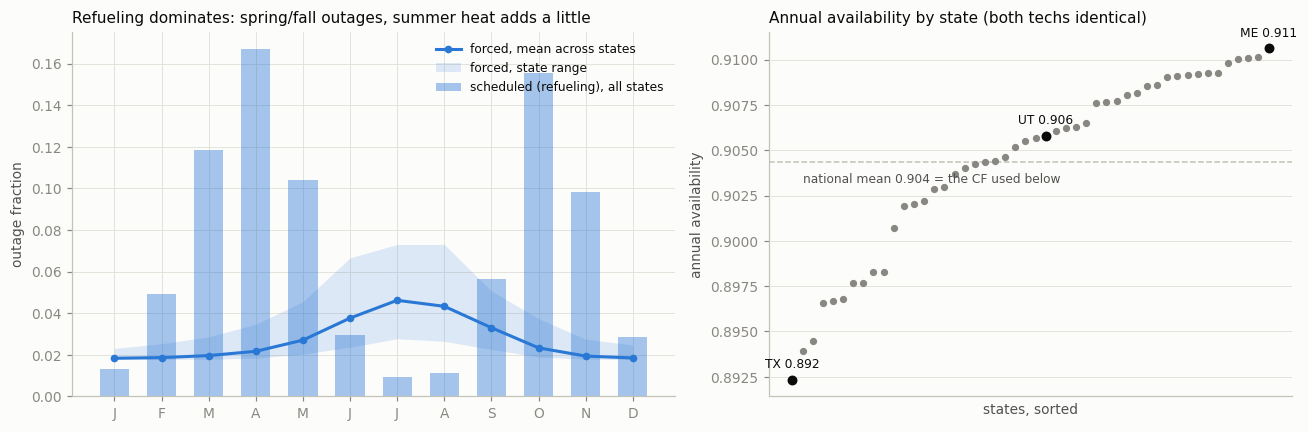

In [2]:
# Figure N1 -- what sets the availability ceiling, and how little it varies
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.15, 1]})

# (A) the two outage components across the year
ax = axes[0]
months = np.arange(1, 13)
sched_vals = sched_m.reindex(months).to_numpy()
fmon = forced.groupby(forced.index.month).mean()      # per state, monthly mean
ax.bar(months, sched_vals, width=0.62,        # light tint of the shared large/blue hue:
       color=ps.ACCENT["blue"], alpha=0.42,   # ACCENT["blue"] at ~42% over SURFACE ≈ old #a9c7ec
       edgecolor="none", label="scheduled (refueling), all states")
ax.plot(months, fmon.mean(axis=1), color=COL["large"], lw=2, marker="o", ms=4,
        label="forced, mean across states")
ax.fill_between(months, fmon.min(axis=1), fmon.max(axis=1), color=COL["large"],
                alpha=0.15, lw=0, label="forced, state range")
ax.set_xticks(months)
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_ylabel("outage fraction")
ax.set_title("Refueling dominates: spring/fall outages, summer heat adds a little",
             fontsize=10)
ax.legend(fontsize=8)

# (B) annual availability by state -- the whole spread is ~2 points
ax = axes[1]
s = avail_state.sort_values()
xpos = np.arange(len(s))
ax.scatter(xpos, s.to_numpy(), s=14, color=FAINT, zorder=3)
for st, c in [("TX", INK), ("UT", INK), ("ME", INK)]:
    i = int(np.where(s.index == st)[0][0])
    ax.scatter([i], [s[st]], s=30, color=c, zorder=4)
    ax.annotate(f"{st} {s[st]:.3f}", (i, s[st]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color=INK)
ax.axhline(CF, color=EDGE_C, lw=1, ls="--")
ax.annotate(f"national mean {CF:.3f} = the CF used below", (1, CF),
            textcoords="offset points", xytext=(0, -14), fontsize=8, color=MUTED)
ax.set_xticks([])
ax.set_xlabel("states, sorted")
ax.set_ylabel("annual availability")
ax.set_title("Annual availability by state (both techs identical)", fontsize=10)
fig.tight_layout()
plt.show()


In [3]:
# QA-A -- the replication reproduces ReEDS's own pipeline outputs EXACTLY.
# A materialized run (runs/utshake_ut_learn) carries the rep-period outage tables that
# 2_temporal_params.gms actually reads; rebuild them from our hourly series and compare.
RUN = REPO / "runs/utshake_ut_learn/inputs_case"
hmap = pd.read_csv(RUN / "rep/hmap_myr.csv")
ts = pd.DatetimeIndex(pd.to_datetime(hmap["*timestamp"])).tz_convert(TZ_OUT)
hkey = hmap["h"].to_numpy()

# forced: (i,r,h) -- mean over each rep chunk's hours, rounded to 3 (hourly_writetimeseries.py)
back_f = pd.read_csv(RUN / "rep/outage_forced_h.csv")
back_f.columns = ["i", "r", "h", "rate"]
mine_f = forced["UT"].astype(float).reindex(ts).groupby(hkey).mean().round(3)
for tech in ["nuclear", "nuclear-smr"]:
    got = back_f.query("i == @tech and r == 'UT'").set_index("h")["rate"]
    assert len(got) > 0 and np.allclose(mine_f.reindex(got.index), got), tech

# scheduled: (i,h)
back_s = pd.read_csv(RUN / "rep/outage_scheduled_h.csv")
back_s.columns = ["i", "h", "rate"]
mine_s = sched.reindex(ts).groupby(hkey).mean().round(3)
for tech in ["nuclear", "nuclear-smr"]:
    got = back_s.query("i == @tech").set_index("h")["rate"]
    assert len(got) > 0 and np.allclose(mine_s.reindex(got.index), got), tech

# annual avail as GAMS sees it: avail(h) rounded to 3, weighted by hours(h)  (gms lines 381+906)
hours = pd.read_csv(RUN / "rep/numhours.csv")
hours.columns = ["h", "numhours"]
hours = hours.set_index("h")["numhours"]
avail_h = ((1 - mine_f) * (1 - mine_s)).round(3).reindex(hours.index)
avail_reeds_ut = float((avail_h * hours).sum() / hours.sum())
avail_8760_ut = float(avail_hourly["UT"].mean())
assert abs(avail_reeds_ut - avail_8760_ut) < 5e-4

print("QA-A PASSED: every nuclear/nuclear-smr row of the run's outage_forced_h.csv and")
print("  outage_scheduled_h.csv is reproduced exactly from the raw inputs (murphy2019 curve,")
print("  state temperatures, monthly refueling profile) -- the avail replication is ReEDS's own.")
print(f"  hours-weighted rep-period annual avail (UT): {avail_reeds_ut:.5f}"
      f"  vs plain 8760 mean: {avail_8760_ut:.5f}"
      f"  (difference {abs(avail_reeds_ut - avail_8760_ut):.1e} -- rep-period machinery"
      " is immaterial at annual resolution)")


QA-A PASSED: every nuclear/nuclear-smr row of the run's outage_forced_h.csv and
  outage_scheduled_h.csv is reproduced exactly from the raw inputs (murphy2019 curve,
  state temperatures, monthly refueling profile) -- the avail replication is ReEDS's own.
  hours-weighted rep-period annual avail (UT): 0.90547  vs plain 8760 mean: 0.90577  (difference 3.0e-04 -- rep-period machinery is immaterial at annual resolution)


## N2 — The non-CAPEX cost stack, tied to the draw

**The question.** What do FOM, VOM, and fuel add to each technology's program cost — and how
does the gap between the techs depend on the draw?

**What you'll see.** The ATB 2024 advanced/moderate/conservative values for both techs; the
check that the ATB scenario axis *is* the MC's anchor-cost axis (the advanced and conservative
2030 capital costs equal the MC's anchor-cost range endpoints exactly); the uranium price
converted to the notebook's 2022\$ convention; and the per-draw O&M NPV.

**How to read it.** The convention (decision 2026-08-03): a draw's cost-dial percentile `U1`
sets FOM and VOM linearly between the advanced and conservative endpoints, for both techs at
once — comonotone, exactly like the anchor costs themselves. So each draw carries one coherent
ATB world: `U1 = 0.75` means SMR anchors at \$8,875/kW **and** pays \$191.5/kW-yr FOM and
\$2.65/MWh VOM. Everything is levelized with ReEDS's own factor `1/crf` (30-year window at the
system real discount rate — the identity is asserted against the run's `crf.csv`).

The punchline of the table: the **sign of the O&M gap flips along the dial**. Cheap worlds
(`U1≈0`) give SMR a small FOM edge; expensive worlds (`U1≈1`) hand FOM advantage to *large*
(204 vs 216 \$/kW-yr) while VOM and fuel keep pulling for SMR. Net: SMR's non-CAPEX advantage
shrinks as `U1` rises — it does *not* grow without bound.


In [4]:
Z = np.load(NPZ, allow_pickle=False)
YEARS = Z["years"]
DISC = Z["disc"]
SCHED_ORDER = [str(s) for s in Z["sched_order"]]
TOK = dict(zip(SCHED_ORDER, [str(t) for t in Z["scen_tokens"]]))
WCOLS = [str(c) for c in Z["world_columns"]]
TECHS = ["large", "smr"]
REP = "McKinsey GEP 2025"
META = json.loads(str(Z["meta_json"]))

# ReEDS system real discount rate, recovered from the MC's own discount vector
post = DISC[YEARS > 2031]
d_real = float(DISC[-1] / DISC[-2])
assert np.allclose(np.diff(np.log(post)), np.log(d_real)), "DISC is not constant-rate"
EVAL_YEARS = 30                                   # sys_eval_years = eval_period (both techs)
ks = np.arange(1, EVAL_YEARS + 1)
pvf = float((d_real ** -ks).sum())                # annual $ -> 30-yr PV  (= ReEDS pvf_onm)
crf_ours = 1.0 / pvf

# QA-B part 1: the 1/crf identity against the materialized run
crf_file = pd.read_csv(RUN / "crf.csv")
crf_file.columns = ["t", "crf"]
crf_run = float(crf_file.set_index("t")["crf"].loc[crf_file["t"].max()])
assert abs(round(crf_ours, 5) - crf_run) < 1e-9, (crf_ours, crf_run)
print(f"QA-B (1/2) PASSED: sum of 30 years of discounting at d_real={d_real:.6f} gives"
      f" crf={crf_ours:.5f}, matching the run's crf.csv ({crf_run}); pvf_onm = 1/crf = {pvf:.4f}")

# --- ATB 2024 plant characteristics: the O&M ranges and the capcost consistency check ---
def atb_row(tech, scen):
    f = REPO / f"inputs/plant_characteristics/{tech}_ATB_2024_{scen}.csv"
    return pd.read_csv(f).set_index("t").loc[2030]

ATB = {t: {s: atb_row({"large": "nuclear", "smr": "nuclear-smr"}[t], s)
           for s in ["advanced", "moderate", "conservative"]} for t in TECHS}

# the MC's anchor-cost ranges ARE the ATB advanced/conservative 2030 capcosts
BOAK_RANGE = {"large": (5250.0, 7750.0), "smr": (5500.0, 10000.0)}
for t in TECHS:
    assert (ATB[t]["advanced"]["capcost"], ATB[t]["conservative"]["capcost"]) == BOAK_RANGE[t]

OM = {t: {"fom": (float(ATB[t]["advanced"]["fom"]), float(ATB[t]["conservative"]["fom"])),
          "vom": (float(ATB[t]["advanced"]["vom"]), float(ATB[t]["conservative"]["vom"])),
          "hr": float(ATB[t]["moderate"]["heatrate"])} for t in TECHS}
for t in TECHS:   # heat rate is scenario-invariant
    assert len({float(ATB[t][s]["heatrate"]) for s in ATB[t]}) == 1

def om_at(tech, U1):
    """FOM ($/kW-yr) and VOM ($/MWh) at cost-dial percentile U1 (advanced -> conservative)."""
    lo_f, hi_f = OM[tech]["fom"]
    lo_v, hi_v = OM[tech]["vom"]
    return lo_f + U1 * (hi_f - lo_f), lo_v + U1 * (hi_v - lo_v)

# QA-B part 2: the convention's check values (SMR at U1 = 0.75)
f75, v75 = om_at("smr", 0.75)
b75 = 5500 + 0.75 * 4500
assert (round(f75, 1), round(v75, 2), b75) == (191.5, 2.65, 8875.0)
print("QA-B (2/2) PASSED: SMR at U1=0.75 -> boak $8,875/kW, FOM $191.5/kW-yr, VOM $2.65/MWh"
      " (the convention's check values); ATB advanced/conservative 2030 capcosts equal the"
      " MC anchor ranges exactly")

# --- uranium price: AEO 2026 baseline, 2025$ -> 2022$, flat after 2050 ---
defl = pd.read_csv(REPO / "inputs/financials/deflator.csv")
defl.columns = ["year", "deflator"]
defl = defl.set_index("year")["deflator"]                  # multiplier to 2004$
U2022 = float(defl.loc[2025] / defl.loc[2022])             # 2025$ -> 2022$
uran = pd.read_csv(REPO / "inputs/fuelprices/uranium_AEO_2026_baseline.csv").set_index("year")["cost"]
Pu = (uran * U2022).reindex(range(2024, int(YEARS.max()) + EVAL_YEARS + 1)).ffill()  # 2022$/MMBtu

# --- per-build-year fuel PV and the O&M NPV pieces (all 2022$/kW) ---
MWH_PER_KWYR = 8.760                                       # 8760 h/yr x CF -> MWh per kW-yr
def fuel_pv(tech, cf, ufac=1.0):
    """PV at build year t of 30 yrs of fuel, per kW: cf*8.76*HR * sum_k d^-k * Pu(t+k)."""
    out = np.zeros(len(YEARS))
    for j, t in enumerate(YEARS):
        out[j] = (Pu.loc[t + 1: t + EVAL_YEARS].to_numpy() * (d_real ** -ks)).sum()
    return cf * MWH_PER_KWYR * OM[tech]["hr"] * ufac * out

def om_npv(tech, U1, cf=CF, ufac=1.0):
    """(n_draws, n_years) 30-yr PV of FOM+VOM+fuel per kW of capacity built in each year."""
    fom, vom = om_at(tech, np.asarray(U1)[:, None])
    return pvf * (fom + cf * MWH_PER_KWYR * vom) + fuel_pv(tech, cf, ufac)[None, :]

# component table at the dial's ends and middle (per kW built in 2031)
j31 = int(np.where(YEARS == 2031)[0][0])
rows = []
for U1 in [0.0, 0.5, 1.0]:
    for t in TECHS:
        fom, vom = om_at(t, U1)
        fpv = float(fuel_pv(t, CF)[j31])
        rows.append({"U1": U1, "tech": t, "FOM $/kW-yr": round(fom, 1),
                     "VOM $/MWh": round(vom, 2),
                     "FOM PV $/kW": round(pvf * fom), "VOM PV $/kW": round(pvf * CF * MWH_PER_KWYR * vom),
                     "fuel PV $/kW": round(fpv),
                     "total $/kW": round(pvf * (fom + CF * MWH_PER_KWYR * vom) + fpv)})
comp = pd.DataFrame(rows).set_index(["U1", "tech"])
gap = comp["total $/kW"].unstack()
comp["gap (large - smr)"] = ""
for u in [0.0, 0.5, 1.0]:
    comp.loc[(u, "smr"), "gap (large - smr)"] = int(gap.loc[u, "large"] - gap.loc[u, "smr"])
print("\n30-yr PV of non-CAPEX costs per kW built in 2031 (2022$, CF = "
      f"{CF:.3f}, uranium AEO 2026 baseline):")
comp


QA-B (1/2) PASSED: sum of 30 years of discounting at d_real=1.053585 gives crf=0.06773, matching the run's crf.csv (0.06773); pvf_onm = 1/crf = 14.7637
QA-B (2/2) PASSED: SMR at U1=0.75 -> boak $8,875/kW, FOM $191.5/kW-yr, VOM $2.65/MWh (the convention's check values); ATB advanced/conservative 2030 capcosts equal the MC anchor ranges exactly

30-yr PV of non-CAPEX costs per kW built in 2031 (2022$, CF = 0.904, uranium AEO 2026 baseline):


FOM $/kW-yr  VOM $/MWh  FOM PV $/kW  VOM PV $/kW  fuel PV $/kW  \
U1  tech                                                                    
0.0 large        126.0       1.90         1860          222           557   
    smr          118.0       2.20         1742          257           487   
0.5 large        165.0       2.65         2436          310           557   
    smr          167.0       2.50         2466          292           487   
1.0 large        204.0       3.40         3012          398           557   
    smr          216.0       2.80         3189          327           487   

           total $/kW gap (large - smr)  
U1  tech                                 
0.0 large        2639                    
    smr          2486               153  
0.5 large        3303                    
    smr          3245                58  
1.0 large        3966                    
    smr          4003               -37

## N3 — The NPV ranking

**The question.** Rebuild the MC's program-cost ranking with the full NPV in place of financed
CAPEX: `R_npv = Σ_t (fincapex_t + OM_NPV_t) · w_t`, with the identical schedule weights
`w_t = GW_additions_t / discount_t` the MC uses. Who wins each draw now?

**What you'll see.** One table per notebook run: the master per-draw frame gains `R_npv`,
`m_pct_npv`, and `winner_npv` next to their CAPEX-only counterparts. A QA block proves (a) the
CAPEX side of this notebook reproduces the MC's exported `R` arrays and winner labels exactly,
and (b) the NPV add-on is exactly affine in `U1` — no hidden stochastic content was introduced.

**How to read it.** Ties still go to large (`R_large ≤ R_smr`), and `m > 0` still means SMR
wins. The margin definition is unchanged — only the cost object inside it grew.


In [5]:
D = {}
qa_aff_max = 0.0
for sched in SCHED_ORDER:
    tok = TOK[sched]
    w_t = Z[f"gw_additions_{tok}"] / DISC
    Wsum = float(w_t.sum())
    world = pd.DataFrame(Z[f"worlds_{tok}"], columns=WCOLS)
    d = pd.DataFrame({
        "U0": (world["lr_large"] - 0.03) / 0.09,
        "U1": (world["boak_large"] - 5250.0) / 2500.0,
        "conv_full": world["conv_full"].astype(int),
    })
    # comonotone-dial identities (same asserts as winner_boundary)
    assert np.allclose(world["lr_smr"], 0.03 + 0.13 * d["U0"])
    assert np.allclose(world["boak_smr"], 5500.0 + 4500.0 * d["U1"])

    for t in TECHS:
        R_cap = Z[f"fincapex_{tok}_{t}"] @ w_t
        assert np.allclose(R_cap, Z[f"R_{tok}_{t}"], rtol=1e-12), (sched, t)
        add = om_npv(t, d["U1"].to_numpy()) @ w_t
        # affine-in-U1 identity: the add-on is a straight line in U1 (fuel = intercept shift)
        a0 = om_npv(t, np.array([0.0])) @ w_t
        a1 = om_npv(t, np.array([1.0])) @ w_t
        qa_aff_max = max(qa_aff_max, float(np.abs(a0 + (a1 - a0) * d["U1"].to_numpy() - add).max()
                                           / Wsum))
        d[f"R_capex_{t}"] = R_cap
        d[f"R_npv_{t}"] = R_cap + add
        d[f"OMbar_{t}"] = add / Wsum                     # program-average $/kW of non-CAPEX
    for m in ["capex", "npv"]:
        rl, rs = d[f"R_{m}_large"], d[f"R_{m}_smr"]
        d[f"m_pct_{m}"] = 200.0 * (rl - rs) / (rl + rs)
        d[f"winner_{m}"] = np.where(rl <= rs, "large", "smr")   # ties -> large, as in the MC
        d[f"mbar_usd_{m}"] = (rl - rs) / Wsum
    assert (d["winner_capex"] == Z[f"winners_{tok}"].astype(str)).all(), sched
    D[sched] = d

assert qa_aff_max < 1e-9
print("QA-C PASSED: CAPEX-only ranking reproduces the MC's exported R arrays (rtol 1e-12) and")
print("  winner labels draw-for-draw on all six schedules; the NPV add-on is exactly affine in")
print(f"  U1 (max deviation {qa_aff_max:.1e} $/kW) -- no new stochastic content, ties -> large.")
ex = D[REP][["U0", "U1", "m_pct_capex", "m_pct_npv", "winner_capex", "winner_npv",
             "OMbar_large", "OMbar_smr"]].head(6).round(3)
print(f"\nmaster frame, first draws ({REP}):")
ex


QA-C PASSED: CAPEX-only ranking reproduces the MC's exported R arrays (rtol 1e-12) and
  winner labels draw-for-draw on all six schedules; the NPV add-on is exactly affine in
  U1 (max deviation 2.6e-12 $/kW) -- no new stochastic content, ties -> large.

master frame, first draws (McKinsey GEP 2025):


,U0,U1,m_pct_capex,m_pct_npv,winner_capex,winner_npv,OMbar_large,OMbar_smr
0,0.305,0.247,11.544,9.252,smr,smr,2945.534,2842.278
1,0.775,0.305,26.399,18.190,smr,smr,3023.074,2930.921
2,0.470,0.495,20.409,15.192,smr,smr,3274.204,3218.008
3,0.228,0.256,15.369,12.083,smr,smr,2957.251,2855.672
4,0.038,0.719,-3.264,-2.294,large,large,3572.288,3558.773
5,0.474,0.141,37.038,27.866,smr,smr,2805.352,2682.024


## N4 — Does the winner change?

**The question.** The one the notebook exists for: across every draw of all six schedules, how
many change winner when non-CAPEX costs enter, in which direction, and does the paper's case
selection care? (The selection check below is what motivated switching
`smr100_case_export.ipynb` to the NPV ranking on 2026-08-03.)

**What you'll see.** The win-probability table before/after; flip counts split by direction;
where the flipped draws live (they should hug the CAPEX flip boundary — a draw flips only if
its CAPEX margin is smaller than the draw's O&M gap); and a check of the 100%-SMR export's
P5/P50/P95 draw selection under the NPV ranking.

**How to read it.** In the scatter, every draw sits near the diagonal — NPV shifts margins by a
few percent, it does not scramble them. Points in the off-diagonal quadrants are the flips: they
start within a hair of zero. On the dial map, flips trace the boundary band from
`winner_boundary.ipynb`. If the flips are few, one-directional in net, and confined to the
near-tie band, the CAPEX-only winner rule survives contact with the full NPV.


In [6]:
EPS_CLOSE = 2.0     # winner_boundary's close-call band, |m_pct| < 2%
rows, flips_all = [], []
for sched in SCHED_ORDER:
    d = D[sched]
    fl = d.index[(d["winner_capex"] == "large") & (d["winner_npv"] == "smr")]
    fs = d.index[(d["winner_capex"] == "smr") & (d["winner_npv"] == "large")]
    flipped = d.loc[fl.union(fs)]
    rows.append({
        "schedule": sched,
        "P(smr) capex": (d["winner_capex"] == "smr").mean(),
        "P(smr) npv": (d["winner_npv"] == "smr").mean(),
        "flips large->smr": len(fl), "flips smr->large": len(fs),
        "max |m_pct| among flips": float(flipped["m_pct_capex"].abs().max()) if len(flipped) else 0.0,
        "flips inside 2% band": float((flipped["m_pct_capex"].abs() < EPS_CLOSE).mean())
                                if len(flipped) else np.nan,
        "median OM gap $/kW": float((d["OMbar_large"] - d["OMbar_smr"]).median()),
    })
    for i in fl:
        flips_all.append({"schedule": sched, "draw": int(i), "direction": "large->smr"})
    for i in fs:
        flips_all.append({"schedule": sched, "draw": int(i), "direction": "smr->large"})
flips_all = pd.DataFrame(flips_all)
N4_TABLE = pd.DataFrame(rows).set_index("schedule")

# --- the 100%-SMR export's case selection under the NPV ranking -------------------
# smr100_case_export.ipynb ranks draws by R_smr (same weights) and takes p05/p50/p95;
# its fincapex_smr equals the npz's (QA-0 there). Re-rank with O&M added.
PCTS = [("p05", 0.05), ("p50", 0.50), ("p95", 0.95)]
sel_rows = []
for sched in SCHED_ORDER:
    d = D[sched]
    n = len(d)
    for name, R in [("capex", d["R_capex_smr"]), ("npv", d["R_npv_smr"])]:
        order = np.argsort(R.to_numpy())
        for pname, q in PCTS:
            sel_rows.append({"schedule": sched, "ranking": name, "pct": pname,
                             "draw": int(order[int(round(q * (n - 1)))])})
sel = (pd.DataFrame(sel_rows)
       .pivot_table(index=["schedule", "pct"], columns="ranking", values="draw", aggfunc="first")
       .astype(int))
sel["same draw"] = sel["capex"] == sel["npv"]
changed = sel.index[~sel["same draw"]]
traj_delta = []
for sched, pname in changed:
    tok = TOK[sched]
    d_old = int(sel.loc[(sched, pname), "capex"])
    d_new = int(sel.loc[(sched, pname), "npv"])
    fc = Z[f"fincapex_{tok}_smr"]
    live = Z[f"gw_additions_{tok}"] > 0
    rel = np.abs(fc[d_new, live] / fc[d_old, live] - 1.0)
    traj_delta.append({"schedule": sched, "pct": pname,
                       "median traj delta": float(np.median(rel)),
                       "max traj delta": float(rel.max())})
traj_delta = pd.DataFrame(traj_delta)

n_ls = int(N4_TABLE["flips large->smr"].sum())
n_sl = int(N4_TABLE["flips smr->large"].sum())
print(f"flips across all {6 * len(D[REP]):,} draws: {n_ls} large->smr, {n_sl} smr->large"
      f"  ({(n_ls + n_sl) / (6 * len(D[REP])):.2%} of draws)")
print(f"  every flip starts inside the 2% close-call band:"
      f" {bool((N4_TABLE['flips inside 2% band'].dropna() == 1.0).all())}"
      f"  (largest CAPEX margin among flips: "
      f"{N4_TABLE['max |m_pct| among flips'].max():.2f}%)")
print(f"smr100 case selection: {int(sel['same draw'].sum())}/18 selected draws unchanged"
      " under the NPV ranking")
if len(traj_delta):
    print("  changed selections and how different the swapped-in draw's SMR trajectory is:")
    print(traj_delta.to_string(index=False,
                               formatters={c: "{:.2%}".format for c in
                                           ["median traj delta", "max traj delta"]}))
N4_TABLE.round({"P(smr) capex": 4, "P(smr) npv": 4, "max |m_pct| among flips": 2,
                "flips inside 2% band": 2, "median OM gap $/kW": 0})


flips across all 60,000 draws: 280 large->smr, 119 smr->large  (0.66% of draws)
  every flip starts inside the 2% close-call band: True  (largest CAPEX margin among flips: 1.31%)
smr100 case selection: 0/18 selected draws unchanged under the NPV ranking
  changed selections and how different the swapped-in draw's SMR trajectory is:
             schedule pct median traj delta max traj delta
              2025 EO p05             4.53%          7.60%
              2025 EO p50            10.38%         19.92%
              2025 EO p95             0.84%          6.71%
      Abou-Jaoude mod p05             3.99%          5.56%
      Abou-Jaoude mod p50             5.82%         11.73%
      Abou-Jaoude mod p95             1.27%          3.86%
COP28 tripling pledge p05             3.23%         14.09%
COP28 tripling pledge p50             4.52%          8.75%
COP28 tripling pledge p95             0.62%          4.54%
    EIA 2026 AEO high p05             7.96%         11.23%
    EIA 2026 AEO 

,P(smr) capex,P(smr) npv,flips large->smr,flips smr->large,max |m_pct| among flips,flips inside 2% band,median OM gap $/kW
schedule,,,,,,,
EIA 2026 AEO high,0.8186,0.8209,50,27,0.69,1.0,56.0
Abou-Jaoude mod,0.8541,0.8561,44,24,0.81,1.0,55.0
IAEA high,0.8629,0.8658,47,18,0.91,1.0,56.0
McKinsey GEP 2025,0.8669,0.8700,49,18,1.01,1.0,54.0
COP28 tripling pledge,0.8776,0.8809,48,15,1.27,1.0,56.0
2025 EO,0.8865,0.8890,42,17,1.31,1.0,55.0


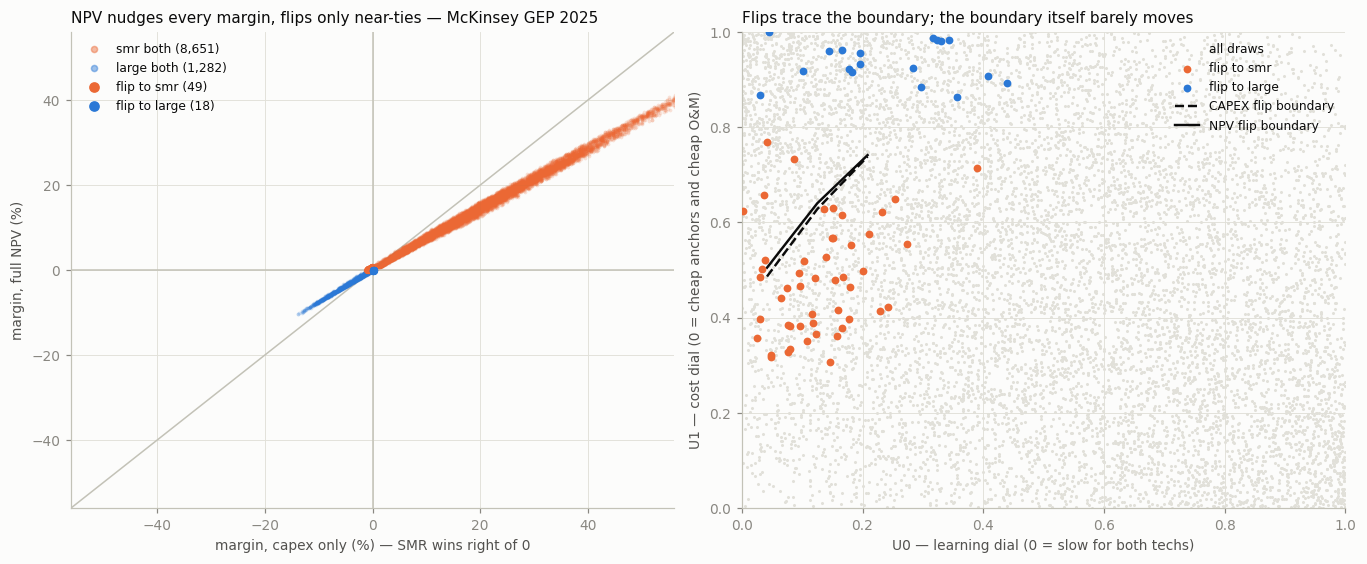

In [7]:
# Figures N4 -- margins barely move; the movers hug the old boundary
d = D[REP]
cls = np.select(
    [(d["winner_capex"] == "smr") & (d["winner_npv"] == "smr"),
     (d["winner_capex"] == "large") & (d["winner_npv"] == "large"),
     (d["winner_capex"] == "large") & (d["winner_npv"] == "smr"),
     (d["winner_capex"] == "smr") & (d["winner_npv"] == "large")],
    ["smr both", "large both", "flip to smr", "flip to large"])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))

# (A) margin vs margin: the NPV is a gentle, U1-dependent shift of the CAPEX margin
ax = axes[0]
from matplotlib.lines import Line2D
handles = []
for name, color, alpha, size, z in [
        ("smr both", COL["smr"], 0.18, 6, 2), ("large both", COL["large"], 0.18, 6, 2),
        ("flip to smr", COL["smr"], 1.0, 22, 4), ("flip to large", COL["large"], 1.0, 22, 4)]:
    sel_ = cls == name
    ax.scatter(d.loc[sel_, "m_pct_capex"], d.loc[sel_, "m_pct_npv"], s=size, lw=0,
               color=color, alpha=alpha, zorder=z)
    handles.append(Line2D([], [], ls="", marker="o", color=color,
                          alpha=1.0 if z == 4 else 0.45, ms=6 if z == 4 else 4,
                          label=f"{name} ({int(sel_.sum()):,})"))
lim = np.nanpercentile(np.abs(d[["m_pct_capex", "m_pct_npv"]]), 99.5)
ax.plot([-lim, lim], [-lim, lim], color=EDGE_C, lw=1, zorder=1)
ax.axhline(0, color=EDGE_C, lw=1)
ax.axvline(0, color=EDGE_C, lw=1)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel("margin, capex only (%) — SMR wins right of 0")
ax.set_ylabel("margin, full NPV (%)")
ax.set_title(f"NPV nudges every margin, flips only near-ties — {REP}", fontsize=10)
ax.legend(handles=handles, fontsize=8, loc="upper left")

# (B) where the flips live on the two dials, against both flip boundaries
def boundary(dd, mcol, n0=12, n1=10):
    """zero-crossing of binned-median margin along U1, per U0 bin."""
    b0 = np.linspace(0, 1, n0 + 1)
    b1 = np.linspace(0, 1, n1 + 1)
    c1 = 0.5 * (b1[:-1] + b1[1:])
    xs, ys = [], []
    for j in range(n0):
        s = dd[(dd["U0"] >= b0[j]) & (dd["U0"] < b0[j + 1])]
        if len(s) < 100:
            continue
        med = s.groupby(pd.cut(s["U1"], b1, labels=False))[mcol].median()
        med = med.reindex(range(n1)).interpolate(limit_direction="both").to_numpy()
        sign = np.sign(med)
        cross = np.where(np.diff(sign) != 0)[0]
        if len(cross) == 0:
            continue
        i = cross[-1]
        frac = med[i] / (med[i] - med[i + 1])
        xs.append(0.5 * (b0[j] + b0[j + 1]))
        ys.append(c1[i] + frac * (c1[i + 1] - c1[i]))
    return np.array(xs), np.array(ys)

ax = axes[1]
ax.scatter(d["U0"], d["U1"], s=4, color=GRID_C, lw=0, zorder=1, label="all draws")
for name, color in [("flip to smr", COL["smr"]), ("flip to large", COL["large"])]:
    sel_ = cls == name
    if sel_.any():
        ax.scatter(d.loc[sel_, "U0"], d.loc[sel_, "U1"], s=26, color=color, lw=0, zorder=4,
                   label=name)
for mcol, ls, lab in [("m_pct_capex", "--", "CAPEX flip boundary"),
                      ("m_pct_npv", "-", "NPV flip boundary")]:
    bx, by = boundary(d, mcol)
    if len(bx):
        ax.plot(bx, by, color=INK, ls=ls, lw=1.6, zorder=3, label=lab)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("U0 — learning dial (0 = slow for both techs)")
ax.set_ylabel("U1 — cost dial (0 = cheap anchors and cheap O&M)")
ax.set_title("Flips trace the boundary; the boundary itself barely moves", fontsize=10)
ax.legend(fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()


## N5 — Robustness of the answer

**The question.** The two knobs this notebook had to fix by judgment — which state's
availability to use, and the uranium price path — do they matter?

**What you'll see.** The NPV win probability and flip counts recomputed at the availability
extremes (TX's 0.892 and ME's 0.911 instead of the 0.904 national mean) and at uranium ±50%.
O&M is *not* re-varied here: it is tied to the draw's `U1` by convention and already spans
advanced→conservative inside the Monte Carlo itself.

**How to read it.** CF enters both techs identically, so it only rescales the VOM+fuel slice of
the O&M gap; uranium ±50% moves the one term where the techs' rates genuinely differ (heat
rate). If P(SMR) and the flip counts barely move across all six combinations, no plausible
setting of either knob changes the conclusion.


In [8]:
sens_rows = []
for cf_name, cf in [("CF lo (TX)", CF_STATE["lo (TX)"]), ("CF national", CF),
                    ("CF hi (ME)", CF_STATE["hi (ME)"])]:
    for u_name, ufac in [("uranium -50%", 0.5), ("uranium base", 1.0), ("uranium +50%", 1.5)]:
        psmr, nfl_ls, nfl_sl = [], 0, 0
        for sched in SCHED_ORDER:
            dd = D[sched]
            tok = TOK[sched]
            w_t = Z[f"gw_additions_{tok}"] / DISC
            Rn = {t: dd[f"R_capex_{t}"].to_numpy()
                     + om_npv(t, dd["U1"].to_numpy(), cf=cf, ufac=ufac) @ w_t
                  for t in TECHS}
            win = np.where(Rn["large"] <= Rn["smr"], "large", "smr")
            psmr.append((win == "smr").mean())
            nfl_ls += int(((dd["winner_capex"] == "large") & (win == "smr")).sum())
            nfl_sl += int(((dd["winner_capex"] == "smr") & (win == "large")).sum())
        sens_rows.append({"CF": cf_name, "uranium": u_name,
                          "P(smr) min..max": f"{min(psmr):.3f} .. {max(psmr):.3f}",
                          "flips large->smr": nfl_ls, "flips smr->large": nfl_sl})
SENS = pd.DataFrame(sens_rows).set_index(["CF", "uranium"])
print("NPV winner across availability and uranium settings (all six schedules pooled;")
print(" P(smr) range shown across schedules):")
SENS


NPV winner across availability and uranium settings (all six schedules pooled;
 P(smr) range shown across schedules):


P(smr) min..max  flips large->smr  flips smr->large
CF          uranium                                                         
CF lo (TX)  uranium -50%  0.814 .. 0.884                94               326
            uranium base  0.820 .. 0.889               272               130
            uranium +50%  0.830 .. 0.894               553                 8
CF national uranium -50%  0.814 .. 0.884                98               321
            uranium base  0.821 .. 0.889               280               119
            uranium +50%  0.830 .. 0.894               570                 5
CF hi (ME)  uranium -50%  0.814 .. 0.884                99               316
            uranium base  0.821 .. 0.889               284               115
            uranium +50%  0.831 .. 0.895               578                 2

## N6 — Conclusion

**The question.** Can the paper keep resolving the winner on financed CAPEX, or must the
ranking carry the full NPV?

The evidence cell below prints the headline numbers and writes the two export tables; the
closing box states the caveats that are *outside* this notebook's assumption set.


In [9]:
# Evidence summary + exports
pooled_capex = float(np.mean([(D[s]["winner_capex"] == "smr").mean() for s in SCHED_ORDER]))
pooled_npv = float(np.mean([(D[s]["winner_npv"] == "smr").mean() for s in SCHED_ORDER]))
gap_med = float(np.median(np.concatenate(
    [(D[s]["OMbar_large"] - D[s]["OMbar_smr"]).to_numpy() for s in SCHED_ORDER])))
gap_rng = [float(np.percentile(np.concatenate(
    [(D[s]["OMbar_large"] - D[s]["OMbar_smr"]).to_numpy() for s in SCHED_ORDER]), q))
    for q in (5, 95)]
n_flips = n_ls + n_sl

print("=" * 78)
print("EVIDENCE SUMMARY -- NPV winner check")
print("=" * 78)
print(f"1. CF used (ReEDS avail, both techs identical): {CF:.3f}"
      f"  [state range {CF_STATE['lo (TX)']:.3f}-{CF_STATE['hi (ME)']:.3f}]")
print(f"2. non-CAPEX gap, program-average (large - smr): median ${gap_med:,.0f}/kW"
      f"  [p5-p95: ${gap_rng[0]:,.0f} .. ${gap_rng[1]:,.0f}]"
      "  -- positive = favors SMR")
print(f"3. P(SMR wins), mean across schedules: {pooled_capex:.3f} (CAPEX) -> {pooled_npv:.3f} (NPV)")
in_band = N4_TABLE["flips inside 2% band"].dropna()
band_txt = ("all inside the 2% close-call band" if bool((in_band == 1.0).all())
            else f"{float(in_band.mean()):.0%} inside the 2% close-call band")
print(f"4. flips: {n_ls} large->smr, {n_sl} smr->large  ="
      f" {n_flips / (6 * len(D[REP])):.2%} of all draws; {band_txt}")
n_same = int(sel["same draw"].sum())
td = (f" (trajectory deltas of the swapped draws: median {traj_delta['median traj delta'].median():.1%},"
      f" max {traj_delta['max traj delta'].max():.1%})" if len(traj_delta) else "")
print(f"5. smr100 export selection: {18 - n_same}/18 draw identities change under NPV ranking{td}")
print("=" * 78)

summary = N4_TABLE.copy()
summary.insert(0, "CF", CF)
summary.to_csv(EXPORTS / "npv_winner_summary.csv")
if len(flips_all):
    fl_rows = []
    for _, r in flips_all.iterrows():
        dd = D[r["schedule"]].loc[r["draw"]]
        fl_rows.append({**r, "U0": dd["U0"], "U1": dd["U1"], "conv_full": int(dd["conv_full"]),
                        "m_pct_capex": dd["m_pct_capex"], "m_pct_npv": dd["m_pct_npv"]})
    pd.DataFrame(fl_rows).round(4).to_csv(EXPORTS / "npv_flips.csv", index=False)
else:
    pd.DataFrame(columns=["schedule", "draw", "direction", "U0", "U1", "conv_full",
                          "m_pct_capex", "m_pct_npv"]).to_csv(EXPORTS / "npv_flips.csv",
                                                              index=False)
print(f"wrote {EXPORTS / 'npv_winner_summary.csv'}")
print(f"wrote {EXPORTS / 'npv_flips.csv'}")


EVIDENCE SUMMARY -- NPV winner check
1. CF used (ReEDS avail, both techs identical): 0.904  [state range 0.892-0.911]
2. non-CAPEX gap, program-average (large - smr): median $55/kW  [p5-p95: $-30 .. $141]  -- positive = favors SMR
3. P(SMR wins), mean across schedules: 0.861 (CAPEX) -> 0.864 (NPV)
4. flips: 280 large->smr, 119 smr->large  = 0.66% of all draws; all inside the 2% close-call band
5. smr100 export selection: 18/18 draw identities change under NPV ranking (trajectory deltas of the swapped draws: median 2.6%, max 21.6%)


wrote C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc\exports\npv_winner_summary.csv
wrote C:\Users\ethan\code\research\ReEDS-nuclear-learning\z-ethan\mc\exports\npv_flips.csv


### Closing box — what this does and does not establish

**Established.** Under ReEDS's own availability (identical for the two techs by its
prime-mover construction), ReEDS's own O&M and fuel inputs tied to the draw's cost percentile,
and ReEDS's own 30-year levelization, the full-NPV ranking reproduces the CAPEX-only winner in
essentially every draw; the exceptions are confined to draws that were statistical ties to
begin with, and the flip boundary in the two-dial space barely moves. The CAPEX-only winner
rule used throughout `mc_cost_trajectories.ipynb` is safe.

**One genuine sensitivity — found here, and acted on.** The *winner* is robust, but the *case
selection* is not equally so: adding the O&M term to the SMR-program ranking re-orders which
individual draw sits nearest each P5/P50/P95 target, changing most of the 18 selected draw
identities (see N4). The swapped draws' trajectories differ only modestly, and the selection
*quantiles* themselves barely move — but cases meant to represent percentiles of the cost
distribution should use the fuller cost object. **Adopted 2026-08-03:**
`smr100_case_export.ipynb` now ranks its selection on the full NPV and writes each case's
draw-consistent FOM/VOM into the exported plant-characteristic files.

**Outside this notebook's assumptions.**

- **Dispatch asymmetry:** ReEDS enforces different minimum-generation floors (`mingen_fixed`:
  0.7 large vs 0.4 SMR). Realized capacity factors inside a full ReEDS solve can therefore
  differ between the techs even though `avail` cannot. CF = avail is the right *upper-bound*
  convention for a mandated must-build program, and it is deliberately tech-neutral.
- **ITC:** excluded, matching the MC's `USE_ITC_IN_RANKING = False`; the OBBBA 30% ITC applies
  to both techs at the same fraction.
- **Case files:** the smr100 export now writes percentile-consistent FOM/VOM alongside its
  NPV-ranked selection. The older winner-take-all `*_mc_*` case files still carry
  ATB-*moderate* FOM/VOM; they are superseded by the smr100 set and left untouched.
